In [1]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt  
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')

pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Arial'

root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'

os.chdir(root_dir)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
df_site    = pd.read_csv('./Data/results/sites_meta_info.csv',index_col=0)

df_SNR     = pd.read_csv('./Data/results/beta_SNR_results.csv',index_col=0)

df_delta_Y = pd.read_csv('./Data/results/delta_Y_CO2_results.csv',index_col=0)

## Fig 3: heatmap of site-specific results

In [3]:
def plot_heatmap_SNR_alltargets(df_SNR_all,df_sort_update,
                                fig,ax,cluster_color_dic,
                                var_plot   = ['Gc','GPP','iWUE'],
                                cluster_new='new_ID',fontsize=13,gap=10):

    cbar_abs_min = 1
    cbar_abs_max = 5
    warm2blue, blue2warm = 'RdBu','RdBu_r' 

    # generate the asymmetric colormap
    warm2blue = customized_asymmetric_cmap_breakpoint(warm2blue,-cbar_abs_max,cbar_abs_max,1,gap,left_part=False)
    blue2warm = customized_asymmetric_cmap_breakpoint(blue2warm,-cbar_abs_max,cbar_abs_max,1,gap,left_part=True)
    
    #---------imshow plot for input contribution---------
    data       = df_SNR_all[var_plot].transpose()

    row_labels = [idx+' SNR' for idx in data.index.tolist()]
    col_labels = df_sort_update.Cover_type + '-' + data.columns
    col_colors = [cluster_color_dic[ID] for ID in df_sort_update[cluster_new].tolist()]
    # n_sites    = data.shape[0]
    
    data1 = data.copy()
    var1  = ['GPP','iWUE'] 
    data1[~data1.index.isin(var1)] = np.nan
    im1   = ax.imshow(data1.values,cmap=warm2blue,vmin=-cbar_abs_min,vmax=cbar_abs_max)
    
    data2 = data.copy()
    var2  = ['Gc'] 
    data2[~data2.index.isin(var2)] = np.nan
    im2   = ax.imshow(data2.values,cmap=blue2warm,vmin=-cbar_abs_max,vmax=cbar_abs_min)
    
    # # --------note cells by slash & dots----------
    # forward_slash(np.argwhere(np.isnan(data.values).T ==True), ax=ax, scale=0.8, color="black",alpha=1,linewidths=0.3)
    
    # add multiple colorbars
    cax1  = ax.inset_axes([0, -1, 0.35, 0.15])
    cbar1 = fig.colorbar(im1,ax=ax,cax=cax1,aspect=60,shrink=0.4,extend='max',orientation='horizontal',pad=0.1) 
    cbar1.ax.set_xlabel(f'SNR for '+(', ').join(var1)+' (dimensionless)', rotation=0, va="bottom",fontsize=fontsize,labelpad=15)
    cbar1.ax.tick_params(labelsize=fontsize-1)
    cbar1.outline.set_visible(False)
    
    cax2  = ax.inset_axes([0.65, -1, 0.35, 0.15])
    cbar2 = fig.colorbar(im2,ax=ax,cax=cax2,aspect=60,shrink=0.4,extend='min',orientation='horizontal',pad=0.1) 
    cbar2.ax.set_xlabel(f'SNR for '+(', ').join(var2)+' (dimensionless)', rotation=0, va="bottom",fontsize=fontsize,labelpad=15)
    cbar2.ax.tick_params(labelsize=fontsize-1)
    cbar2.outline.set_visible(False)
    
    #-----------set the tick & ticklabels, add white grid----------
    n_y,n_x = data.shape
    # Major ticks
    ax.set_xticks(np.arange(0, n_x, 1), labels=col_labels,fontsize=10,rotation=90)
    ax.set_yticks(np.arange(0, n_y, 1), labels=row_labels,fontsize=14,fontweight='bold')
    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,labeltop=True, labelbottom=False)
    # Minor ticks
    ax.set_xticks(np.arange(-.5, n_x, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_y, 1), minor=True)
    # Gridlines based on minor ticks
    ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
    # Remove minor ticks
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.spines[:].set_color('white')
    # set xticklabel colors
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(col_colors[i])


def customized_asymmetric_cmap_breakpoint(default_cmap,vmin,vmax,break_abs,gap,
                                          left_part=True):

    cmap = plt.get_cmap(default_cmap)

    
    N = cmap.N
    break1 = int(N/(vmax-vmin) * (-break_abs - vmin))
    break2 = int(N/(vmax-vmin) * (break_abs - vmin))
    middle = N//2

    colors = [cmap(i) for i in range(cmap.N)]

    if left_part:
        left_half = colors[:middle - gap]
        n_org = len(left_half)

        # Interpolate to recover the original size (n = break1)
        assert n_org > break1
        indices = np.linspace(0, n_org - 1, break1).astype(int)
        left_half = [left_half[i] for i in indices]

        colors    = np.concatenate([left_half,[cmap(middle)] * (break2 - break1)])

    else:
        right_half = colors[middle + gap:]
        n_org = len(right_half)

        # Interpolate to recover the original size (n = N - break2)
        assert n_org > N - break2
        indices = np.linspace(0, n_org - 1, N - break2).astype(int)
        right_half = [right_half[i] for i in indices]

        colors     = np.concatenate([[cmap(middle)] * (break2 - break1),right_half])

    # Create the custom colormap
    custom_cmap = mcolors.LinearSegmentedColormap.from_list('CustomRdBu', colors, len(colors))

    
    return custom_cmap


def boxplot_three_patterns(data,fig,ax,cluster_color_dic,legend_loc,legend=False):
    # prepare data format 
    list = []
    for var in ['Gc','GPP','iWUE']:
        df_var = data[[var,'new_ID']].reset_index()
        df_var = df_var.rename(columns={var:'value'})
        df_var['var'] = var
        list.append(df_var)
    df_boxplot = pd.concat(list,axis=0)
    df_boxplot = df_boxplot.reset_index(drop=True)
    
    # plot the main part
    ax.axhline(y = 0, color = 'black', linestyle = '--',linewidth=0.8,alpha=0.5) 
    boxplot = sns.boxplot(x='new_ID', y='value', data=df_boxplot, hue='var',
                          palette=None,saturation=1,ax=ax,
                          fliersize=3,showfliers=False,width=0.7,linewidth=1) #  ,legend=False
    for i, line in enumerate(boxplot.get_lines()):
        line.set_color('black')
    
    # add legend
    boxplot.legend_.remove()
    
    if legend:
        handles, labels = boxplot.get_legend_handles_labels()
        l = ax.legend(handles, labels, title=None, bbox_to_anchor=legend_loc, 
                      loc='upper left',ncols=3,columnspacing=0.8,handletextpad=0.2)
        for i, lp, in enumerate(l.get_patches()):
            if i == 0:
                lp.set_facecolor('none')
            if i == 1:
                lp.set_facecolor('none')
                lp.set_hatch('///')
            if i == 2:
                lp.set_facecolor('grey')
            lp.set_edgecolor('black')
    
    # edit color & hatch
    for i,patch, in enumerate(boxplot.patches):
        patch.set_edgecolor('black')
        patch.set_facecolor('none')
    
        if i in [1,6,9]:
            patch.set_hatch('')
            patch.set_edgecolor(get_color(i,cluster_color_dic))
    
        if i in [3,7,10]:
            patch.set_hatch('///')
            patch.set_edgecolor(get_color(i,cluster_color_dic))
    
        if i in [5,8,11]:
            patch.set_facecolor(get_color(i,cluster_color_dic))
            patch.set_edgecolor(get_color(i,cluster_color_dic))


def get_color(i,cluster_color_dic):
    if i in [1,3,5]:
        return cluster_color_dic[1]
    if i in [6,7,8]:
        return cluster_color_dic[2]
    if i in [9,10,11]:
        return cluster_color_dic[3]
        




In [4]:
data_SNR  = pd.DataFrame(index=df_SNR.index)
targets = ['Gc','GPP','iWUE']
for var in targets:
    data_SNR[var] = df_SNR[var+'_SNR'].values

data_beta  = pd.DataFrame(index=df_SNR.index)
targets = ['Gc','GPP','iWUE']
for var in targets:
    data_beta[var] = df_SNR[var+'_beta'].values

data_decomp  = pd.DataFrame(index=df_delta_Y.index)
targets = ['Gc','GPP','iWUE']
for target in targets:
    data_decomp[target] = df_delta_Y['delta_'+target+'_CO2'].values

In [5]:
cluster_color_dic = {1:'#0072B2',2:'#E69F00',3:'#CC79A7'}  

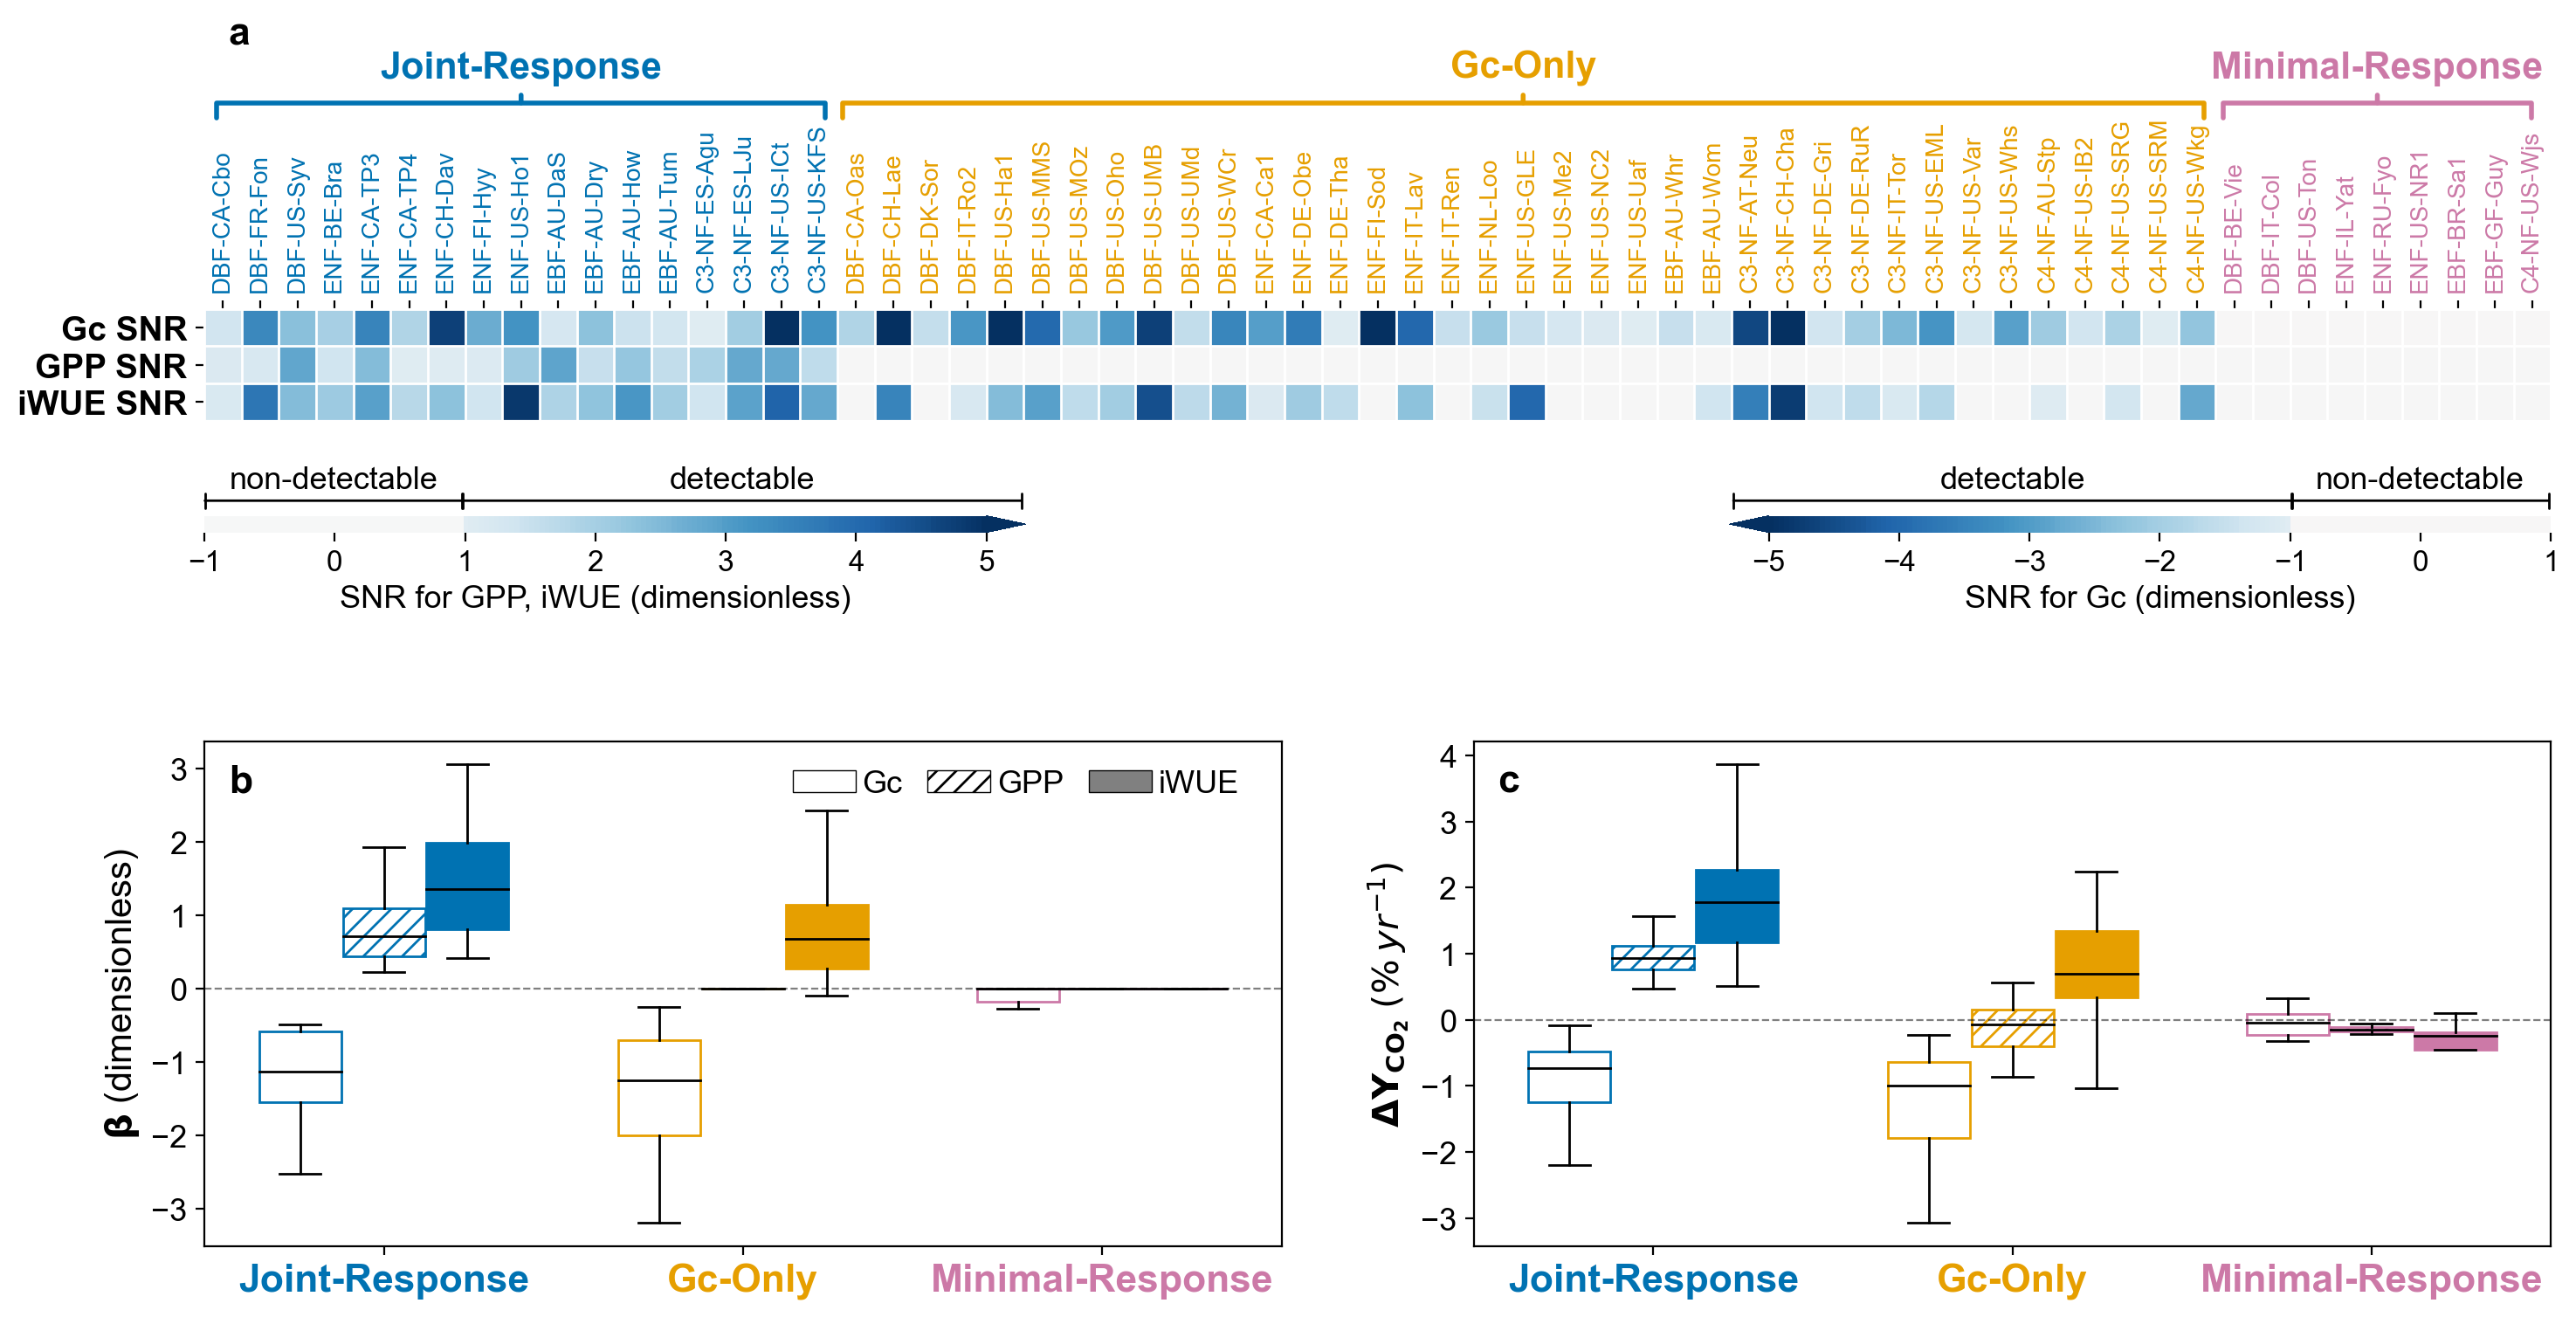

In [6]:
fig = plt.figure(figsize=(15,8))

shape = (7,2)
ax1 = plt.subplot2grid(shape, loc=(0,0), colspan=2,rowspan=4)
ax2 = plt.subplot2grid(shape, (4,0), colspan=1,rowspan=3)
ax3 = plt.subplot2grid(shape, (4,1), colspan=1,rowspan=3)

# ---------------- plot the heatmap for site-specific results ----------------
plot_heatmap_SNR_alltargets(data_SNR,df_SNR,
                            fig,ax1,cluster_color_dic,
                            var_plot=['Gc','GPP','iWUE'],gap=15)


# denote the non-detectable regime
x1, x2 = 0.0825, 0.1845
y      = 0.595
start  = (x1, y)
end    = (x2, y)
arrow  = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.2,widthB=0.2', mutation_scale=15, color='black')
fig.add_artist(arrow)
fig.text((x1+x2)/2, y+0.015, 'non-detectable', 
         ha='center', va='center',fontsize=13,  color='black') 

x1 += 0.747 + 0.0445 + 0.005
x2 += 0.747 + 0.0445 + 0.005
start  = (x1, y)
end    = (x2, y)
arrow  = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.2,widthB=0.2', mutation_scale=15, color='black')
fig.add_artist(arrow)
fig.text((x1+x2)/2, y+0.015, 'non-detectable', ha='center', va='center',fontsize=13,  color='black') # 


# denote the detectable regime
x1 = 0.181
x2 = x1 + 0.217
start  = (x1, y)
end    = (x2, y)
arrow  = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.2,widthB=0.2', mutation_scale=15, color='black')
fig.add_artist(arrow)
fig.text((x1+x2)/2, y+0.015, 'detectable', ha='center', va='center',fontsize=13,  color='black') # 

x1 += 0.4355 + 0.0445 + 0.005
x2 += 0.4355 + 0.0445 + 0.005
start  = (x1, y)
end    = (x2, y)
arrow  = FancyArrowPatch(start, end, arrowstyle='|-|,widthA=0.2,widthB=0.2', mutation_scale=15, color='black')
fig.add_artist(arrow)
fig.text((x1+x2)/2, y+0.015, 'detectable', ha='center', va='center',fontsize=13,  color='black') # 



y_loc = 2.8
label_fontsize = 15.5
y_dis = 0.2
# Updating the 'Joint-driven' annotation
ax1.annotate('Joint-Response', xy=(0.135, y_loc), xytext=(0.135, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[1], fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=8.1, lengthB=0.4', lw=2.0, color=cluster_color_dic[1]),
            textcoords='axes fraction')

# Updating the 'Gc-only' annotation
ax1.annotate('Gc-Only', xy=(0.562, y_loc), xytext=(0.562, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[2], fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=18.1, lengthB=0.4', lw=2.0, color=cluster_color_dic[2]),
            textcoords='axes fraction')

ax1.annotate('Minimal-Response', xy=(0.926, y_loc), xytext=(0.926, y_loc + y_dis), xycoords='axes fraction', 
            fontsize=label_fontsize, ha='center', va='bottom', color=cluster_color_dic[3], fontweight='bold',
            arrowprops=dict(arrowstyle='-[, widthB=4.1, lengthB=0.4', lw=2.0, color=cluster_color_dic[3]),
            textcoords='axes fraction')


# -----------boxplot for beta & delta_Y_CO2-----------
data       = data_beta.merge(df_SNR['new_ID'],left_index=True,right_index=True)
boxplot_three_patterns(data,fig,ax2,cluster_color_dic,(0.52,1),legend=True)

data       = data_decomp.merge(df_SNR['new_ID'],left_index=True,right_index=True)
boxplot_three_patterns(data,fig,ax3,cluster_color_dic,(0.55,1),legend=False)

ylabels  = [r'$\mathbf{\beta}$ (dimensionless)',r'$\mathbf{\Delta Y_{CO_2}}$ $(\% \: yr^{-1})$']
subpanel = ['b','c']
for i,ax in enumerate([ax2,ax3]):
    ax.set_ylabel(ylabels[i],fontsize=15)
    ax.set_xticklabels(['Joint-Response', 'Gc-Only','Minimal-Response'],fontweight='bold',fontsize=16)
    ax.set_xlabel('')
    ax.annotate(subpanel[i],xy=(10,187), xycoords='axes points',fontweight='bold',fontsize=16)
    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(cluster_color_dic[i+1])

ax1.annotate('a',xy=(10,155), xycoords='axes points',fontweight='bold',fontsize=16)

# plt.subplots_adjust(hspace=1.8)
plt.tight_layout()

# plt.savefig(os.path.join(fig_dir,f'fig_3_heatmap_Gc_v2.svg'),format='svg')